In [1]:
# Import Necessary Library

In [2]:
#import library

import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.optimizers import Nadam,Adamax,Adam
from tensorflow.keras.metrics import Precision,Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Kaggle Dataset Download

In [4]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [5]:
TRAIN_DIR = os.path.join(path,"Training")
TEST_DIR = os.path.join(path,"Testing")

print("Training",TRAIN_DIR)
print("Testing",TEST_DIR)

Training /kaggle/input/brain-tumor-mri-dataset/Training
Testing /kaggle/input/brain-tumor-mri-dataset/Testing


In [6]:
print(os.listdir(TRAIN_DIR))
print(os.listdir(TEST_DIR))

['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [7]:
# Create Data Frame

In [8]:
def create_dataframe(data_dir):
  data = []
  for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir,class_name)

    if not os.path.isdir(class_dir):
      continue

    for filename in os.listdir(class_dir):
      if filename.lower().endswith((".jpg",".jepg",".png",".bmp",".webp")):
        filepath = os.path.join(class_dir,filename)
        data.append({
              "filepath":filepath,
              "label":class_name,
              "filename":filename
          })

  return pd.DataFrame(data)

In [9]:
train_df = create_dataframe(TRAIN_DIR)
test_df = create_dataframe(TEST_DIR)

In [10]:
train_df.head()

,filepath,label,filename
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary,Tr-pi_124.jpg
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary,Tr-pi_949.jpg
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary,Tr-pi_786.jpg
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary,Tr-pi_371.jpg
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary,Tr-pi_599.jpg


In [11]:
# Data Frame Shape

In [12]:
print("Training shape",train_df.shape)
print("Testing shape",test_df.shape)

Training shape (5600, 3)
Testing shape (1600, 3)


In [13]:
# Class Distribution

In [14]:
print(train_df.label.value_counts())

label
pituitary     1400
notumor       1400
meningioma    1400
glioma        1400
Name: count, dtype: int64


In [15]:
# Visualization

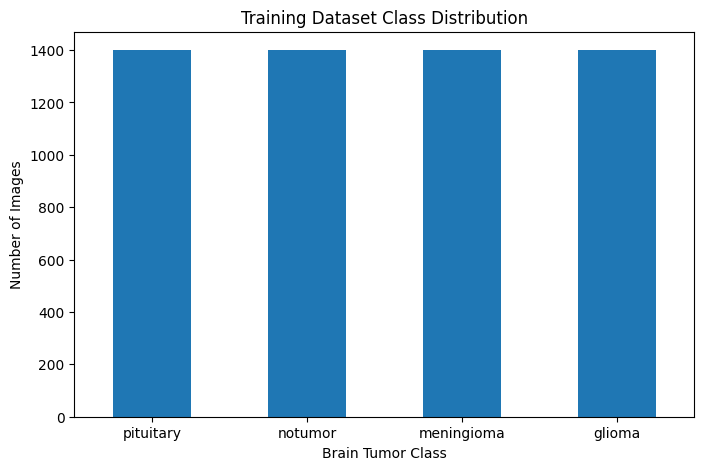

In [16]:
plt.figure(figsize=(8,5))
train_df["label"].value_counts().plot(kind="bar")

plt.title("Training Dataset Class Distribution")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

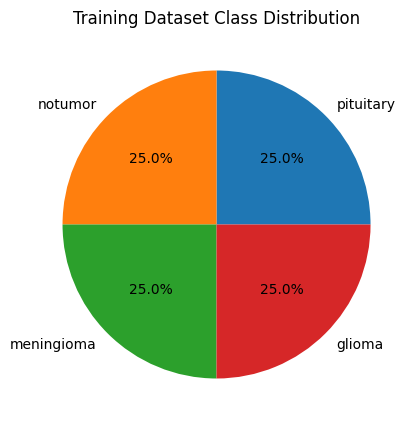

In [17]:
plt.figure(figsize=(8,5))
train_df["label"].value_counts().plot(kind="pie",
                                      autopct="%1.1f%%")

plt.title("Training Dataset Class Distribution")
plt.ylabel("")
plt.xticks(rotation=0)
plt.show()

In [18]:
# Sample Image Visualization

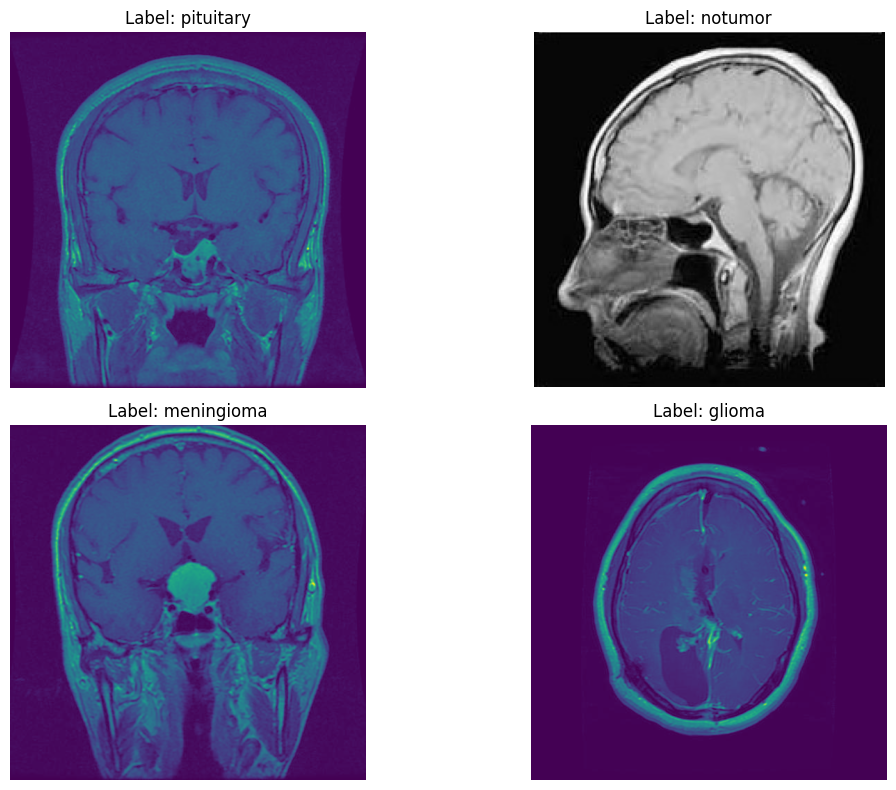

In [19]:
#sample image visualization from dataframe

classes = train_df["label"].unique()

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):
  sample = train_df[train_df["label"] == class_name].sample(1).iloc[0]

  image = Image.open(sample["filepath"])
  plt.subplot(2,2,i+1)
  plt.imshow(image)
  plt.title(f"Label: {sample['label']}")
  plt.axis("off")

plt.tight_layout()
plt.show()

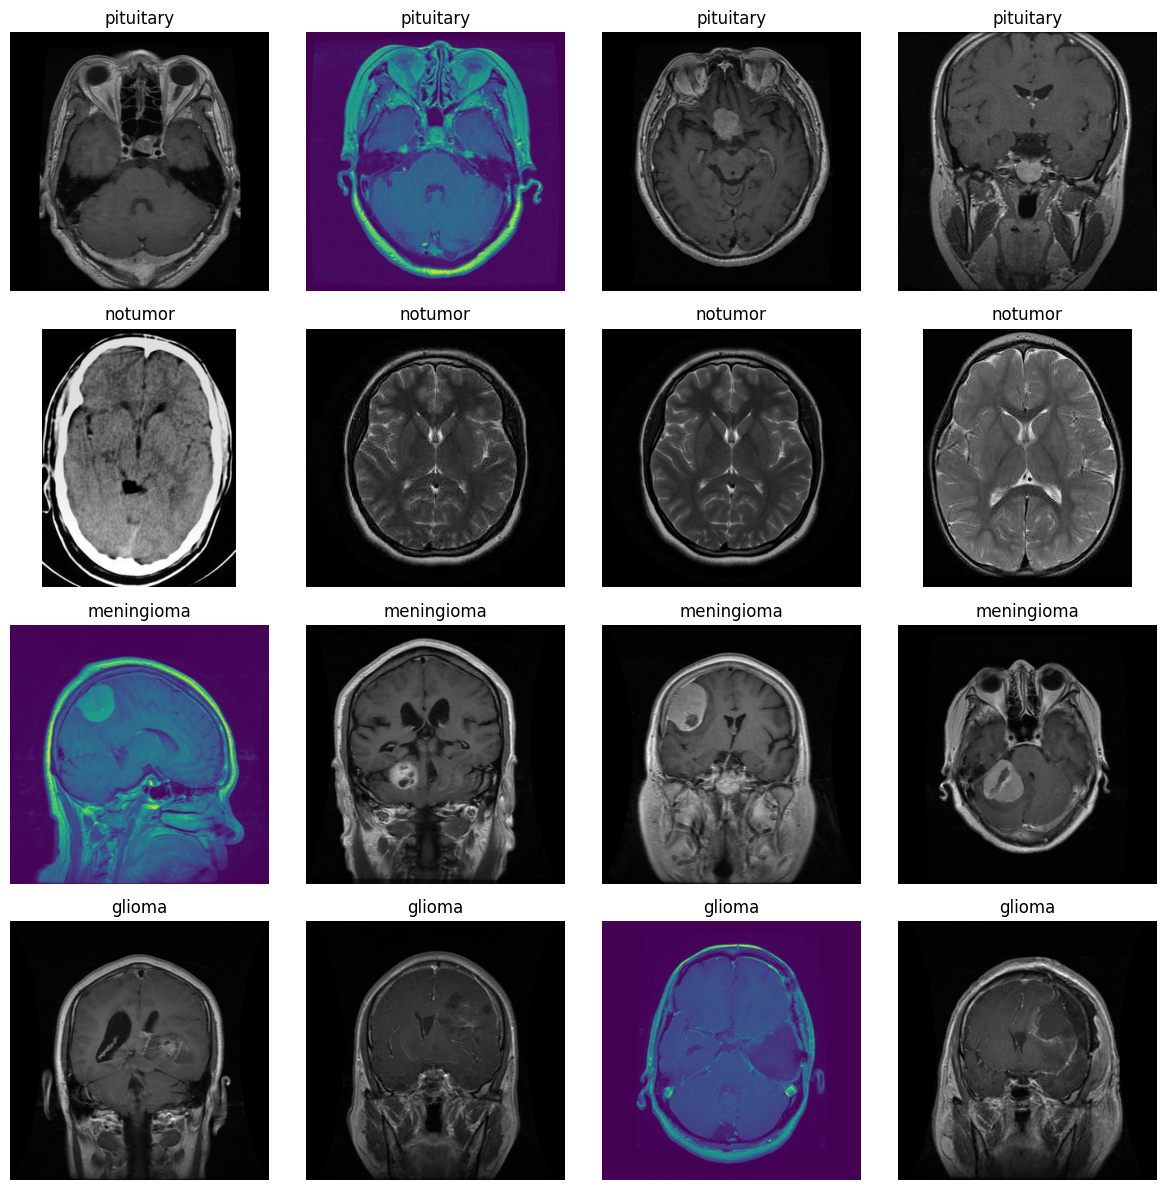

In [20]:
# 4 images from each class

plt.figure(figsize=(12, 12))

for row, class_name in enumerate(classes):

    samples = train_df[
        train_df["label"] == class_name
    ].sample(4)

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["filepath"])

        plt.subplot(4, 4, row * 4 + col + 1)

        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Image Size Analysis

In [22]:
def get_image_size(filepath):
  image = Image.open(filepath)
  return image.size

In [23]:
sample_df = train_df.sample(500, random_state=42).copy()

sample_df["size"] = sample_df["filepath"].apply(
    get_image_size
)

sample_df["width"] = sample_df["size"].apply(
    lambda x: x[0]
)

sample_df["height"] = sample_df["size"].apply(
    lambda x: x[1]
)

sample_df.head()

,filepath,label,filename,size,width,height
4795,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,Tr-gl_694.jpg,"(512, 512)",512,512
4269,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma,Tr-gl_61.jpg,"(512, 512)",512,512
2004,/kaggle/input/brain-tumor-mri-dataset/Training...,notumor,Tr-no_973.jpg,"(200, 252)",200,252
2515,/kaggle/input/brain-tumor-mri-dataset/Training...,notumor,Tr-no_931.jpg,"(512, 512)",512,512
3014,/kaggle/input/brain-tumor-mri-dataset/Training...,meningioma,Tr-me_351.jpg,"(512, 512)",512,512


In [24]:
# Visualization

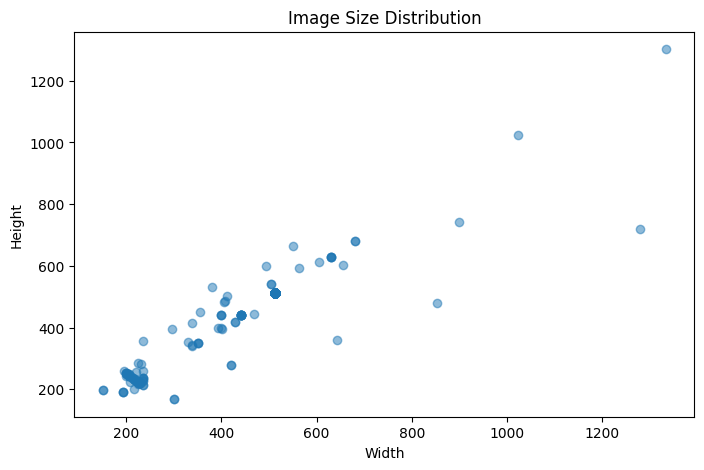

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sample_df["width"],
    sample_df["height"],
    alpha=0.5
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

In [26]:
# Train Test Split

In [27]:
test_df,val_df = train_test_split(test_df,train_size=0.5,random_state=20,stratify=test_df["label"])

print("Test shape",test_df.shape)
print("Validation shape",val_df.shape)

Test shape (800, 3)
Validation shape (800, 3)


In [28]:
# Image Data Generator

In [29]:
IMG_SIZE = (299,299)
BATCH_SIZE = 32

In [30]:
train_datagen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

test_datagen = ImageDataGenerator(rescale=1/255)

In [31]:
train_generator = train_datagen.flow_from_dataframe(train_df, x_col='filepath',
                                  y_col='label', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE)

valid_generator = train_datagen.flow_from_dataframe(val_df, x_col='filepath',
                                     y_col='label', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE)

test_generator = test_datagen.flow_from_dataframe(test_df, x_col='filepath',
                                  y_col='label', batch_size=16,
                                  target_size=IMG_SIZE, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [32]:
# Image Visualization from Image Generator

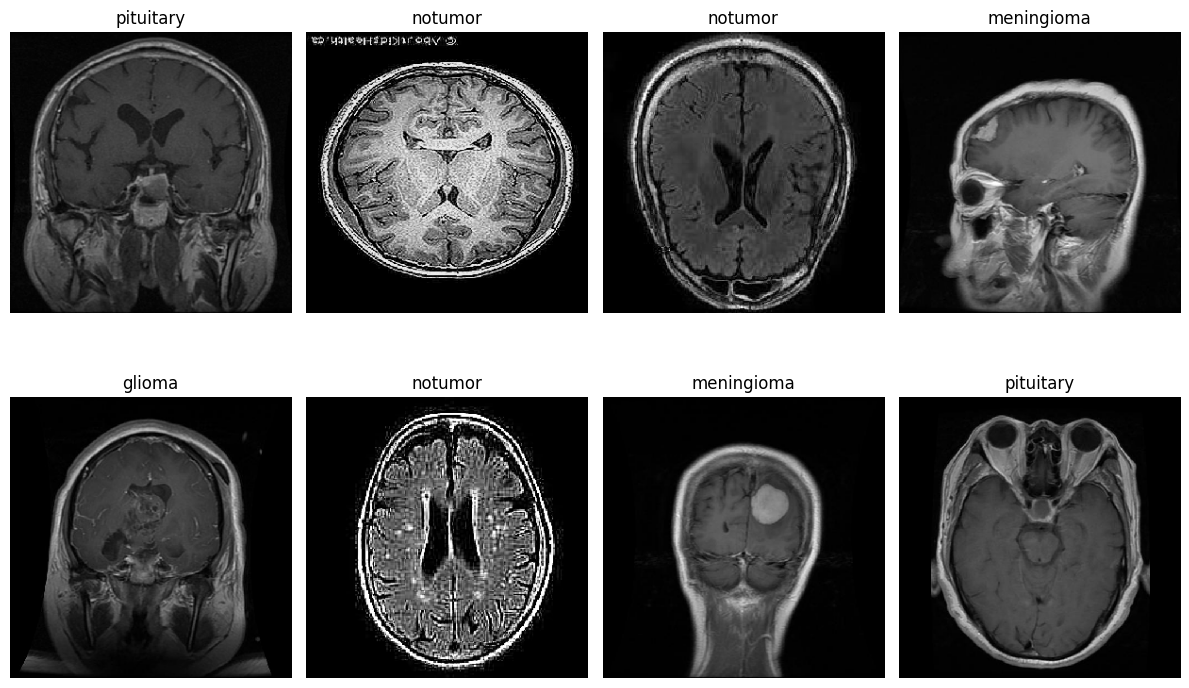

In [33]:
images, labels = next(train_generator)

class_names = list(
    train_generator.class_indices.keys()
)

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    label_index = labels[i].argmax()

    plt.title(
        class_names[label_index]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
# Building Deep Learning Model

In [35]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

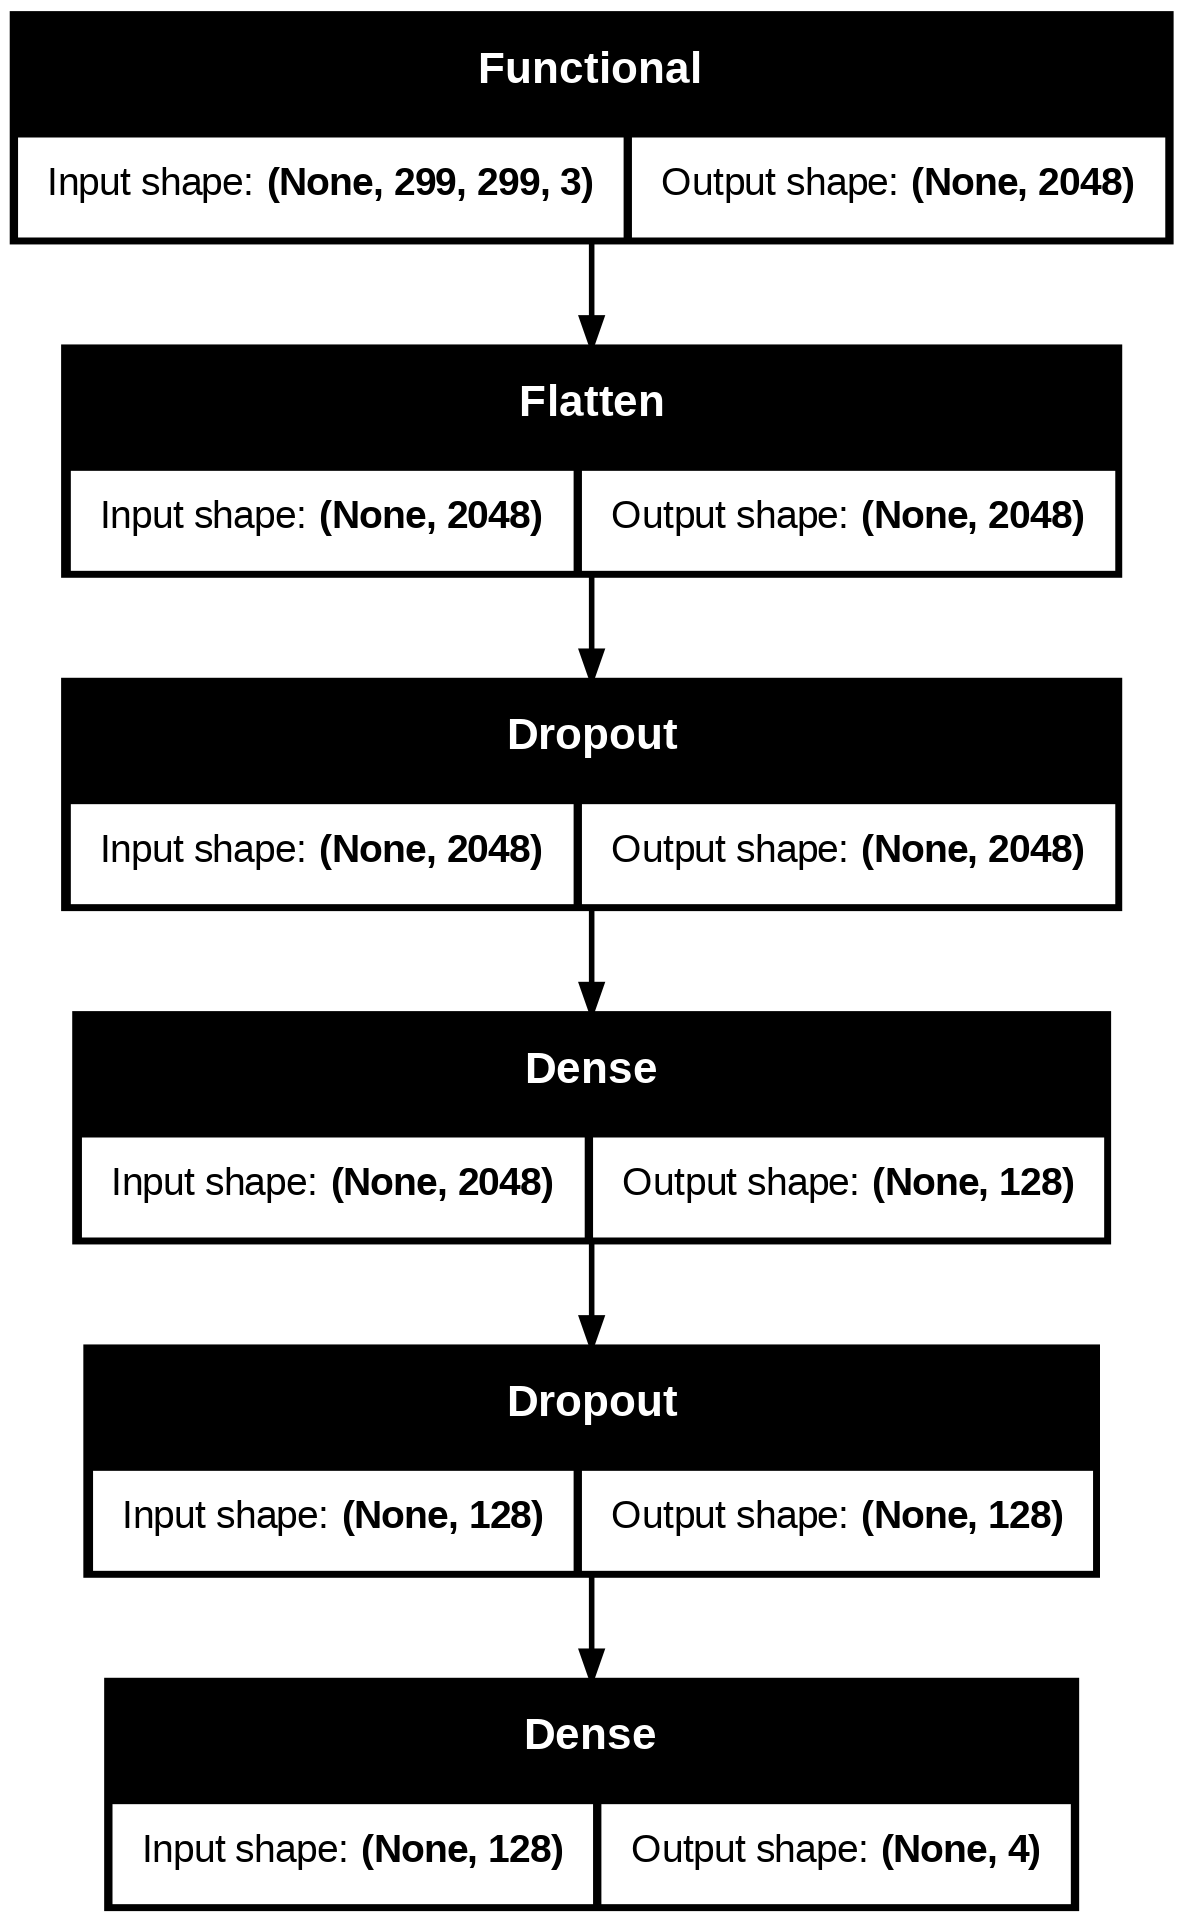

In [36]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [37]:
# Traning

In [38]:
hist = model.fit(train_generator,
                 epochs=10,
                 validation_data=valid_generator,
                 shuffle= False)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.8314 - loss: 0.4631 - precision: 0.8971 - recall: 0.7659 - val_accuracy: 0.8525 - val_loss: 0.5415 - val_precision: 0.8566 - val_recall: 0.8512
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9736 - loss: 0.0806 - precision: 0.9748 - recall: 0.9727 - val_accuracy: 0.8963 - val_loss: 0.3903 - val_precision: 0.8985 - val_recall: 0.8963
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9902 - loss: 0.0339 - precision: 0.9904 - recall: 0.9896 - val_accuracy: 0.9200 - val_loss: 0.4447 - val_precision: 0.9212 - val_recall: 0.9200
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9962 - loss: 0.0131 - precision: 0.9964 - recall: 0.9961 - val_accuracy: 0.9375 - val_loss: 0.4646 - val_precision: 0.9410 - val_recall: 0.9375
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9952 - loss: 0.0152 - precision: 0.9952 - recall: 0.9952 - val_accuracy: 0.9312 - val_los

In [39]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

In [40]:
# Visualize Model Performance

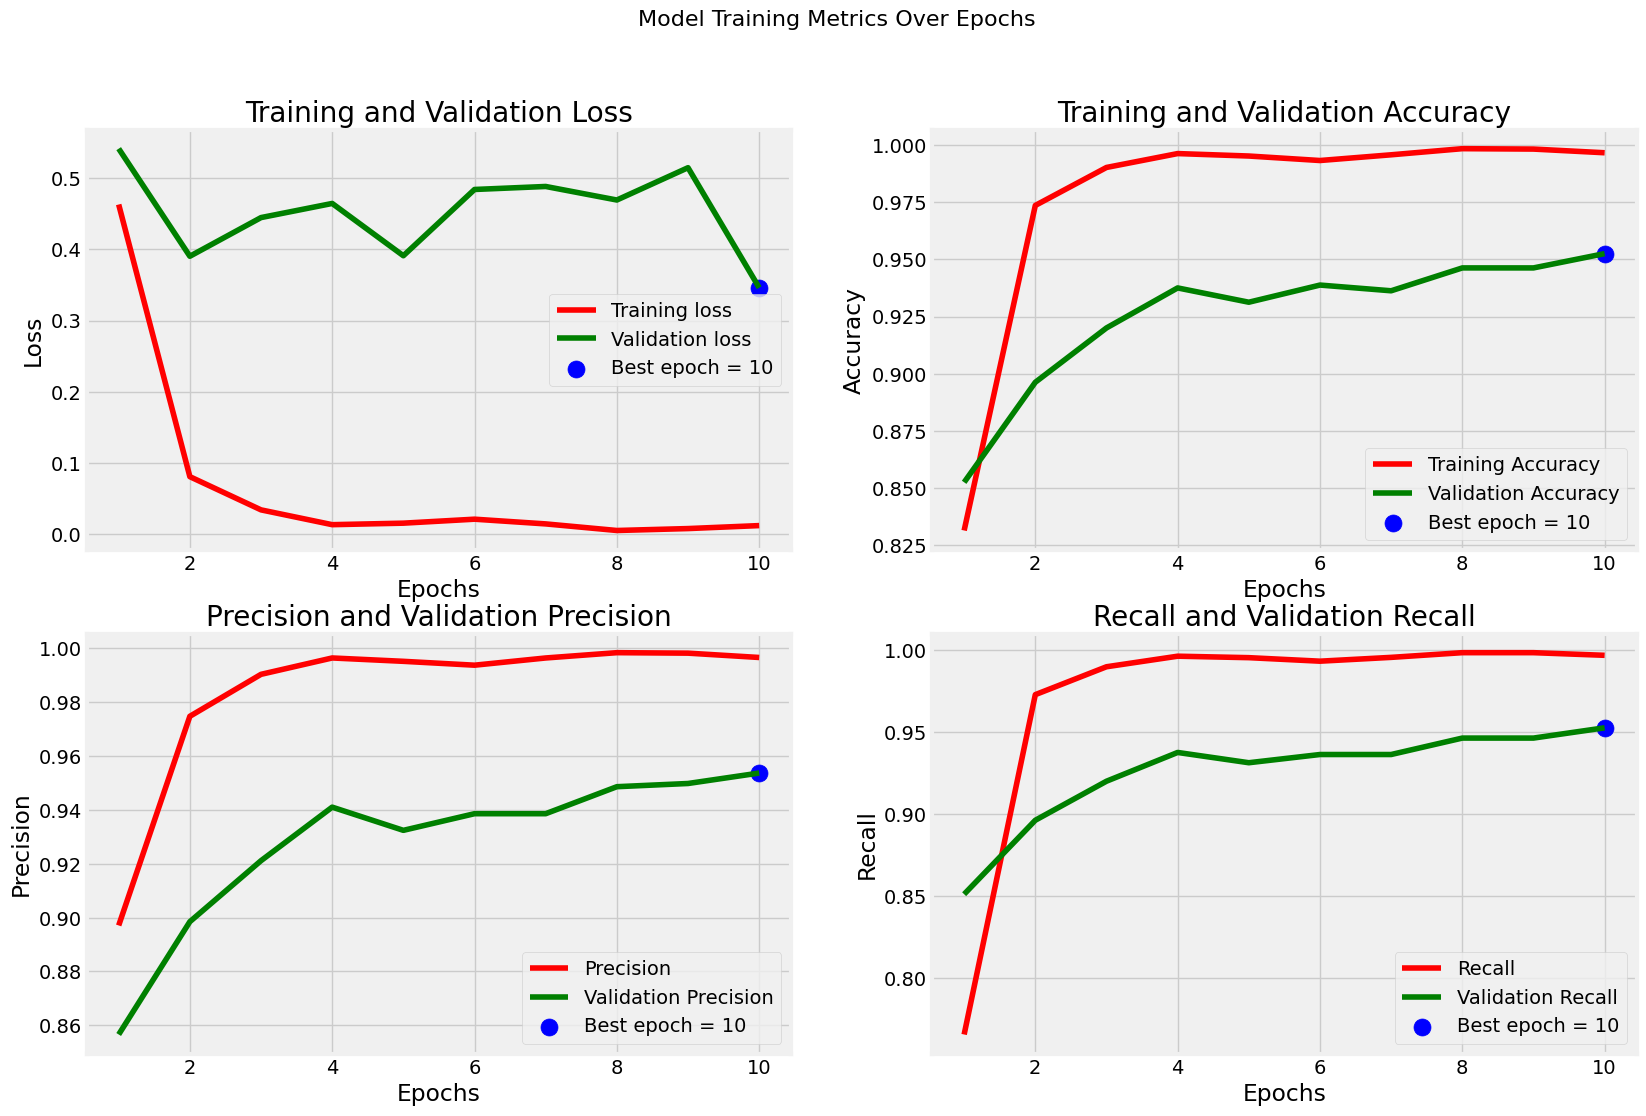

In [41]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()


In [42]:
# Testing And Evaluation

In [43]:
train_score = model.evaluate(train_generator, verbose=1)
valid_score = model.evaluate(valid_generator, verbose=1)
test_score = model.evaluate(test_generator, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 308ms/step - accuracy: 0.9991 - loss: 0.0022 - precision: 0.9991 - recall: 0.9991
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.9525 - loss: 0.3512 - precision: 0.9525 - recall: 0.9525
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.9500 - loss: 0.3533 - precision: 0.9499 - recall: 0.9488
Train Loss: 0.0022
Train Accuracy: 99.91%
--------------------
Validation Loss: 0.3512
Validation Accuracy: 95.25%
--------------------
Test Loss: 0.3533
Test Accuracy: 95.00%


In [44]:
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step


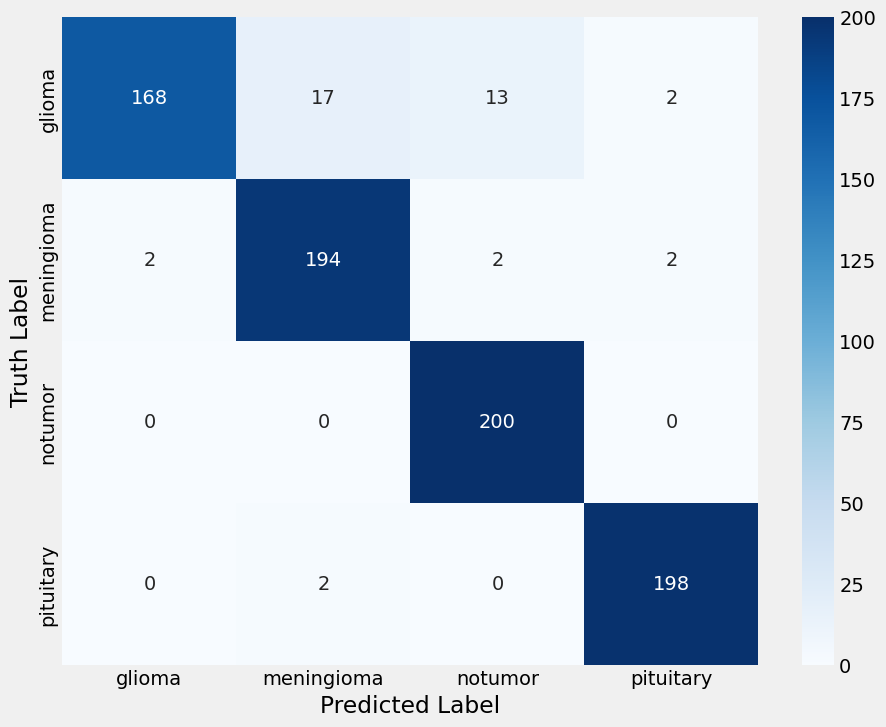

In [45]:
cm = confusion_matrix(test_generator.classes, y_pred)
labels = list(train_generator.class_indices.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [46]:
# Testing

In [60]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image

    labels = list(train_generator.class_indices.keys())

    # Load image
    img = Image.open(img_path)

    # IMPORTANT: Convert grayscale/RGBA/etc. to RGB
    img = img.convert("RGB")

    # Resize
    resized_img = img.resize((299, 299))

    # Convert PIL image to NumPy
    img_array = np.array(resized_img, dtype=np.float32)

    # Normalize
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    print("Input shape:", img_array.shape)

    # Prediction
    predictions = model.predict(img_array, verbose=0)

    probs = predictions[0]

    predicted_index = np.argmax(probs)
    predicted_label = labels[predicted_index]
    confidence = probs[predicted_index] * 100

    # Display
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(resized_img)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_label}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.subplot(1, 2, 2)
    bars = plt.bar(labels, probs)
    plt.ylabel("Probability")
    plt.xlabel("Class")
    plt.xticks(rotation=30)

    for bar, prob in zip(bars, probs):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{prob:.2%}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    return predicted_label, confidence

Input shape: (1, 299, 299, 3)


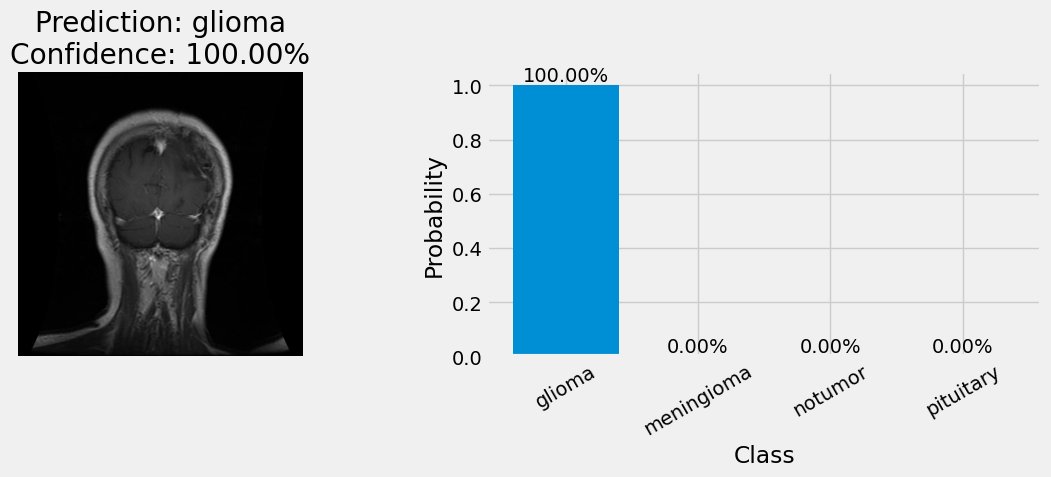

('glioma', np.float32(100.0))

In [62]:
predict('/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_694.jpg')

Input shape: (1, 299, 299, 3)


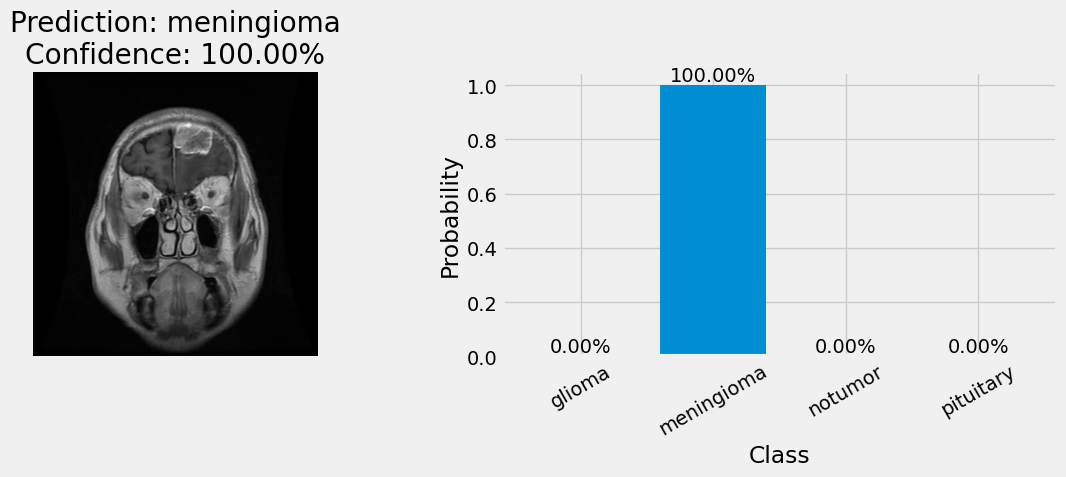

('meningioma', np.float32(99.997055))

In [64]:
predict("/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_351.jpg")

Input shape: (1, 299, 299, 3)


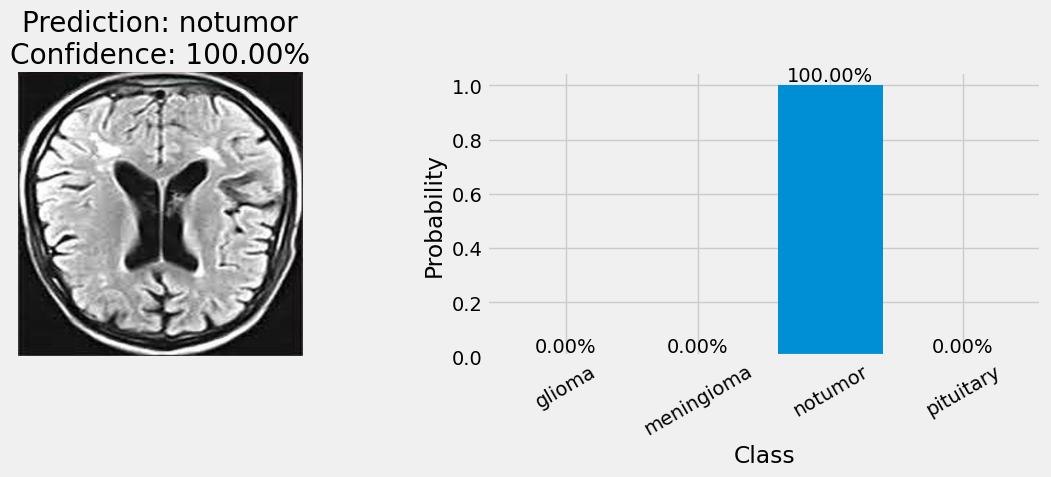

('notumor', np.float32(99.99998))

In [65]:
predict("/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_973.jpg")